In [376]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd

from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm



sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale as ART_down
from function import ART_statistic as ART_stat

import warnings
warnings.filterwarnings('ignore')

In [377]:
product, time_reso, reso = 'IMERG', '1dy', '10'
# product, time_reso, reso = 'CMORPH', '3h', '25'
# product, time_reso, reso = 'CHIRPS', '1dy', '5'

# product, time_reso, reso = 'ERA5', '3h', '25'
# product, time_reso, reso = 'MSWEP', '3h', '10'
# product, time_reso, reso = 'GSMaP', '3h', '10'

In [378]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy')
obs_base = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [379]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [380]:
dir_sat = os.path.join(dir_base, 'Satellite', '4_GEV', 'raw')

data_dir = os.path.join(dir_sat, f'ITALY_GEV_{product}_{time_reso}_2002_2023.nc')
DATA = xr.open_dataset(data_dir)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)

In [381]:
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d, lat2d)

In [382]:
csi_IT = DATA.csi.where(mask_italy).values
psi_IT = DATA.psi.where(mask_italy).values
mu_IT = DATA.mu.where(mask_italy).values

GEVs = DATA.GEVs.where(mask_italy).values

In [383]:
pos = 3
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)
print(f'Return Time: {Tr[pos]} yrs')

Return Time: 50 yrs


In [384]:
METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy_CLEAR.csv'))
print(f'Number of Stations: {len(METADATA)}')

Number of Stations: 2910


In [ ]:
def linear_bc_through_origin(obs, sat, sat_all):
    df = pd.DataFrame({'OBS': obs, 'SAT': sat})
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    x = df['SAT'].values
    y = df['OBS'].values

    alpha = np.sum(x * y) / np.sum(x**2)

    # aplicar corrección
    sat_corrected = sat_all * alpha

    return sat_corrected

In [386]:
lat_list, lon_list = [], []
factor_csi_list, factor_psi_list, factor_mu_list = [], [], []

csi_obs_list, csi_sat_list = [], []
GEV_obs_list, file_list = [], []

for nn in range(len(METADATA)):
    file = METADATA['File'].values[nn]
    ISO = METADATA['ISO'].values[nn]
    lon_obs = METADATA['Lon'].values[nn]
    lat_obs = METADATA['Lat'].values[nn]

    data_obs = os.path.join(f'/media/arturo/T9/Data/Italy/Rain_Gauges_QC/data/raw/1dy/{ISO}/{file}')
    OBS_data = pd.read_csv(data_obs)
    OBS_data['Datetime'] = pd.to_datetime(OBS_data['Datetime'])

    OBS_data = OBS_data[
        (OBS_data['Datetime'].dt.year >= 2002) & 
        (OBS_data['Datetime'].dt.year <= 2023)]

    OBS_year_max = (OBS_data.groupby(OBS_data['Datetime'].dt.year)['pre'].max())

    obs_excess = OBS_year_max.values[OBS_year_max.values > 1] - 1

    if len(obs_excess) <= 2:
        continue
    else:
        csi_obs, psi_obs, mu_obs = DOWN_raw.gev_fit_lmom(obs_excess)
        GEV_obs = DOWN_raw.gev_quant(Fi, csi_obs, psi_obs, mu_obs)

        sat_pixel = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')
        csi_sat, psi_sat, mu_sat = float(sat_pixel.csi.values), float(sat_pixel.psi.values), float(sat_pixel.mu.values)

        factor_csi = np.nanmedian(csi_obs) / np.nanmedian(csi_sat+0.6)
        factor_psi = np.nanmedian(psi_obs) / np.nanmedian(psi_sat)
        factor_mu = np.nanmedian(mu_obs) / np.nanmedian(mu_sat)

        lat_list.append(lat_obs)
        lon_list.append(lon_obs)

        csi_obs_list.append(csi_obs)
        csi_sat_list.append(csi_sat+0.6)

        factor_csi_list.append(factor_csi)
        factor_psi_list.append(factor_psi)
        factor_mu_list.append(factor_mu)

        GEV_obs_list.append(GEV_obs[3])
        file_list.append(file)

Factor_csi_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'csi_obs':csi_obs_list, 'csi_sat':csi_sat_list, 'factor':factor_csi_list})
Factor_psi_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_psi_list})
Factor_mu_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_mu_list})
Quantile_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'GEV_obs':GEV_obs_list, 'File':file_list})

In [387]:
factor_csi_grid = ART_stat.interpolate_factors_to_grid(Factor_csi_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)

factor_psi_grid = ART_stat.interpolate_factors_to_grid(Factor_psi_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)

factor_mu_grid = ART_stat.interpolate_factors_to_grid(Factor_mu_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)

In [388]:
factor_csi_grid = factor_csi_grid.where(mask_italy).values
factor_psi_grid = factor_psi_grid.where(mask_italy).values
factor_mu_grid = factor_mu_grid.where(mask_italy).values

In [389]:
# csi_corrected = csi_IT*factor_csi_grid
psi_corrected = psi_IT*factor_psi_grid
mu_corrected = mu_IT*factor_mu_grid

In [ ]:
csi_corrected = linear_bc_through_origin(np.array(csi_obs_list), np.array(csi_sat_list), csi_IT)

In [391]:
GEV_corrrected = np.zeros([len(Fi),len(lats),len(lons)])
for i in range(len(lats)):
    for j in range(len(lons)):
        GEV_corrrected[:,i,j] = DOWN_raw.gev_quant(Fi, csi_corrected[i,j], psi_corrected[i,j], mu_corrected[i,j])

In [392]:
Quantile_df = Quantile_df[Quantile_df['GEV_obs']<600]

In [393]:
Gev_levels = np.arange(50, 510, 10)
Gev_cmap = plt.cm.Spectral_r
norm = BoundaryNorm(Gev_levels, ncolors=Gev_cmap.N, clip=True)

Text(0.0, 1.0, '(b) GEV Quantiles Corrected')

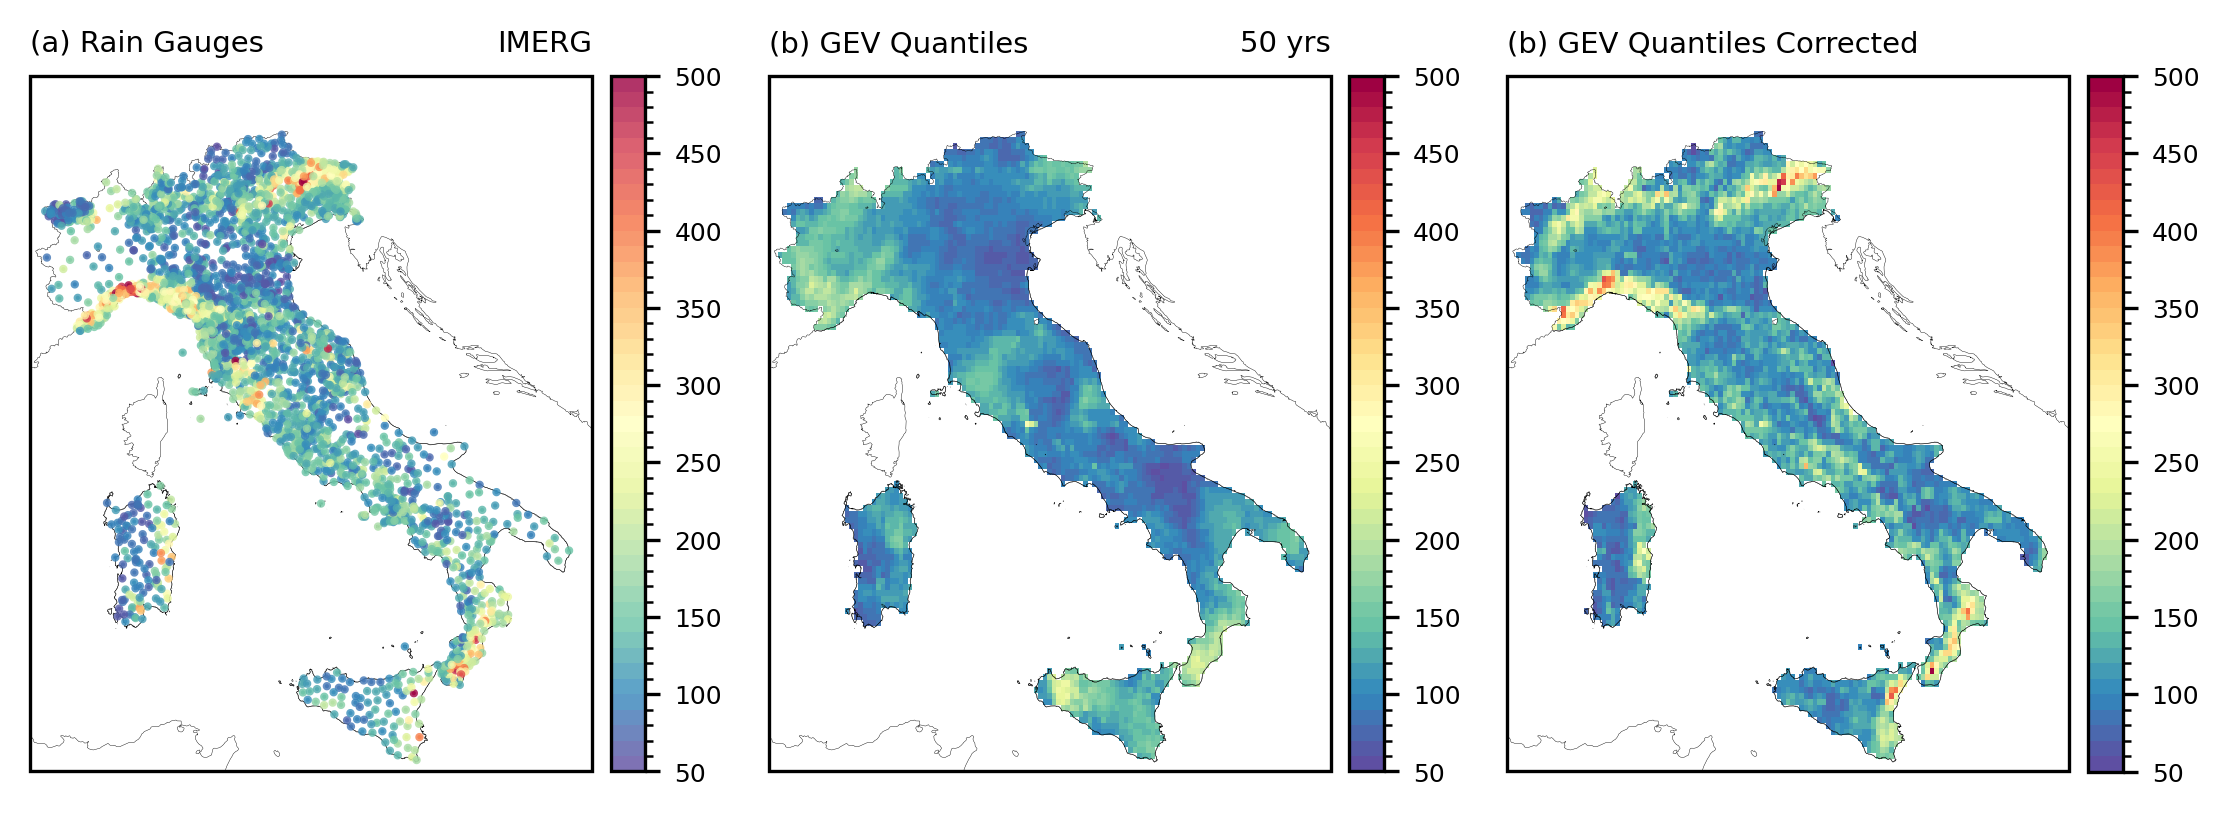

In [394]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,5),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.scatter(Quantile_df['lon'].values, Quantile_df['lat'].values, c=Quantile_df['GEV_obs'].values, s=1, alpha=0.8,cmap=Gev_cmap,norm=norm, zorder=10)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03)
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(a) Rain Gauges', loc='left', fontsize=7)
ax1.set_title(product, loc='right', fontsize=7)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, GEVs[3,:,:], cmap=Gev_cmap, norm=norm)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03)
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(b) GEV Quantiles', loc='left', fontsize=7)
ax1.set_title(f'{Tr[pos]} yrs', loc='right', fontsize=7)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, GEV_corrrected[3,:,:], cmap=Gev_cmap, norm=norm)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03)
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(b) GEV Quantiles Corrected', loc='left', fontsize=7)

In [395]:
DOWN_corrected = xr.Dataset(
        data_vars={
            "csi": (("lat","lon"), csi_corrected),
            "psi": (("lat","lon"), psi_corrected),
            "mu": (("lat","lon"), mu_corrected),
            "GEVs": (("Tr","lat","lon"), GEV_corrrected),
            },
        coords={
            'lat': lats, 
            'lon': lons,
            'Tr': Tr,
            },
            attrs=dict(description=f"{product} Weibull parameters and GEV corrected applying in Italy",))

DOWN_corrected.csi.attrs["units"] = "# days"
DOWN_corrected.csi.attrs["long_name"] = "Corrected GEV csi Parameter"
DOWN_corrected.csi.attrs["origname"] = "GEV csi"

DOWN_corrected.psi.attrs["units"] = "nondimensional"
DOWN_corrected.psi.attrs["long_name"] = "Corrected GEV psi Parameter"
DOWN_corrected.psi.attrs["origname"] = "GEV psi"

DOWN_corrected.mu.attrs["units"] = "nondimensional"
DOWN_corrected.mu.attrs["long_name"] = "Corrected GEV mu Parameter"
DOWN_corrected.mu.attrs["origname"] = "GEV mu"

DOWN_corrected.GEVs.attrs["units"] = "mm/day"
DOWN_corrected.GEVs.attrs["long_name"] = "Corrected GEV Extreme Quantiles"
DOWN_corrected.GEVs.attrs["origname"] = "GEV quantiles"

DOWN_corrected.lat.attrs["units"] = "degrees_north"
DOWN_corrected.lat.attrs["long_name"] = "Latitude"

DOWN_corrected.lon.attrs["units"] = "degrees_east"
DOWN_corrected.lon.attrs["long_name"] = "Longitude"

PRE_out = os.path.join(os.path.join(dir_base, 'Satellite', '4_GEV','corrected',f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
print(f'Exportin as: {PRE_out}')
DOWN_corrected.to_netcdf(PRE_out)
print()

Exportin as: /media/arturo/T9/Data/Italy/Satellite/4_GEV/corrected/ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc



In [396]:
pos_list = [1, 3, 4, 5]
for pos in pos_list:
    print(f'Return time: {Tr[pos]} years') 
    dir_out = os.path.join('/','home','arturo','github','downpy','output','geotiff','GEV_corrected',f'{product}_GEVc_{reso}km_{Tr[pos]}_yrs.tif')
    ART_stat.export_geotiff(GEV_corrrected[pos, :, :],lats,lons,'GEV',dir_out)

Return time: 10 years
Return time: 50 years
Return time: 100 years
Return time: 200 years
